This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [1]:
!pip install keras keras-hub --upgrade -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-nlp 0.21.1 requires keras-hub==0.21.1, but you have keras-hub 0.26.0 which is incompatible.


In [2]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [3]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Timeseries forecasting

### Different kinds of timeseries tasks

### A temperature forecasting example

In [4]:
!wget https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
!unzip jena_climate_2009_2016.csv.zip

--2026-03-05 03:00:05--  https://s3.amazonaws.com/keras-datasets/jena_climate_2009_2016.csv.zip
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.217.114.168, 54.231.137.144, 16.182.104.216, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.217.114.168|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 13565642 (13M) [application/zip]
Saving to: ‘jena_climate_2009_2016.csv.zip’

jena_climate_2009_2 100%[===================>]  12.94M  20.7MB/s    in 0.6s    

2026-03-05 03:00:06 (20.7 MB/s) - ‘jena_climate_2009_2016.csv.zip’ saved [13565642/13565642]

Archive:  jena_climate_2009_2016.csv.zip
  inflating: jena_climate_2009_2016.csv  
  inflating: __MACOSX/._jena_climate_2009_2016.csv  


In [5]:
import os

fname = os.path.join("jena_climate_2009_2016.csv")

with open(fname) as f:
    data = f.read()

lines = data.split("\n")
header = lines[0].split(",")
lines = lines[1:]
print(header)
print(len(lines))

['"Date Time"', '"p (mbar)"', '"T (degC)"', '"Tpot (K)"', '"Tdew (degC)"', '"rh (%)"', '"VPmax (mbar)"', '"VPact (mbar)"', '"VPdef (mbar)"', '"sh (g/kg)"', '"H2OC (mmol/mol)"', '"rho (g/m**3)"', '"wv (m/s)"', '"max. wv (m/s)"', '"wd (deg)"']
420451


In [6]:
import numpy as np

temperature = np.zeros((len(lines),))
raw_data = np.zeros((len(lines), len(header) - 1))

for i, line in enumerate(lines):
    values = [float(x) for x in line.split(",")[1:]]
    temperature[i] = values[1]
    raw_data[i, :] = values[:]

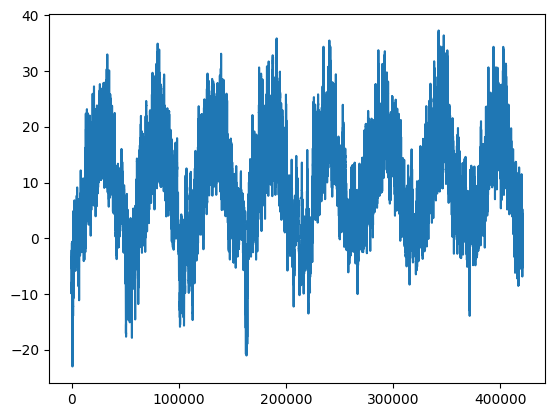

In [7]:
from matplotlib import pyplot as plt

plt.plot(range(len(temperature)), temperature)

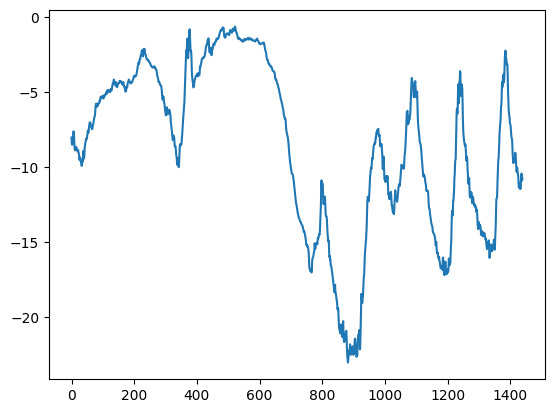

In [8]:
plt.plot(range(1440), temperature[:1440])

In [9]:
num_train_samples = int(0.5 * len(raw_data))
num_val_samples = int(0.25 * len(raw_data))
num_test_samples = len(raw_data) - num_train_samples - num_val_samples
print("num_train_samples:", num_train_samples)
print("num_val_samples:", num_val_samples)
print("num_test_samples:", num_test_samples)

num_train_samples: 210225
num_val_samples: 105112
num_test_samples: 105114


#### Preparing the data

In [10]:
mean = raw_data[:num_train_samples].mean(axis=0)
raw_data -= mean
std = raw_data[:num_train_samples].std(axis=0)
raw_data /= std

In [11]:
import numpy as np
import keras

int_sequence = np.arange(10)
dummy_dataset = keras.utils.timeseries_dataset_from_array(
    data=int_sequence[:-3],
    targets=int_sequence[3:],
    sequence_length=3,
    batch_size=2,
)

for inputs, targets in dummy_dataset:
    for i in range(inputs.shape[0]):
        print([int(x) for x in inputs[i]], int(targets[i]))

[0, 1, 2] 3
[1, 2, 3] 4
[2, 3, 4] 5
[3, 4, 5] 6
[4, 5, 6] 7


In [12]:
sampling_rate = 6
sequence_length = 120
delay = sampling_rate * (sequence_length + 24 - 1)
batch_size = 256

train_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=num_train_samples,
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples,
    end_index=num_train_samples + num_val_samples,
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    raw_data[:-delay],
    targets=temperature[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=num_train_samples + num_val_samples,
)

In [13]:
for samples, targets in train_dataset:
    print("samples shape:", samples.shape)
    print("targets shape:", targets.shape)
    break

samples shape: (256, 120, 14)
targets shape: (256,)


#### A commonsense, non-machine-learning baseline

In [14]:
def evaluate_naive_method(dataset):
    total_abs_err = 0.0
    samples_seen = 0
    for samples, targets in dataset:
        preds = samples[:, -1, 1] * std[1] + mean[1]
        total_abs_err += np.sum(np.abs(preds - targets))
        samples_seen += samples.shape[0]
    return total_abs_err / samples_seen

print(f"Validation MAE: {evaluate_naive_method(val_dataset):.2f}")
print(f"Test MAE: {evaluate_naive_method(test_dataset):.2f}")

Validation MAE: 2.44
Test MAE: 2.62


#### Let's try a basic machine learning model

In [15]:
import keras
from keras import layers

inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Flatten()(inputs)
x = layers.Dense(16, activation="relu")(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_dense.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_dense.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 12.8062 - mae: 2.7269 - val_loss: 10.6283 - val_mae: 2.5848
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 8.1480 - mae: 2.2491 - val_loss: 10.7339 - val_mae: 2.5896
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 7.4298 - mae: 2.1451 - val_loss: 10.7437 - val_mae: 2.5877
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 6.9427 - mae: 2.0730 - val_loss: 11.1592 - val_mae: 2.6323
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 52ms/step - loss: 6.6216 - mae: 2.0253 - val_loss: 11.0702 - val_mae: 2.6214
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 6.4008 - mae: 1.9927 - val_loss: 11.4644 - val_mae: 2.6617
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 41s 50ms/step - loss: 6.2290 - mae: 1.9670 - val_loss: 11.2194 - val_mae: 2.6341
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 6.1068 - mae: 1.9467 - val_loss: 11.6227 - val_mae: 2.6743
Epoch 9/10
819/819 ━━━━━━━━━━━━

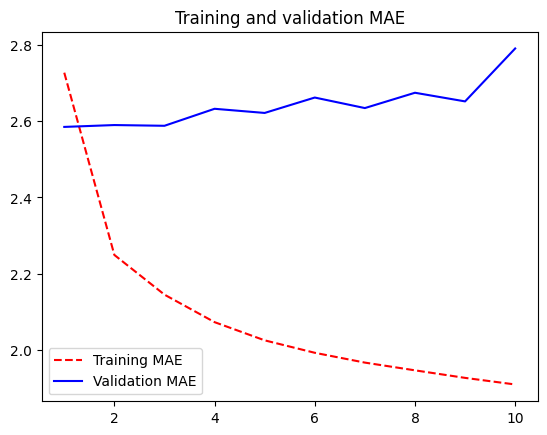

In [16]:
import matplotlib.pyplot as plt

loss = history.history["mae"]
val_loss = history.history["val_mae"]
epochs = range(1, len(loss) + 1)
plt.figure()
plt.plot(epochs, loss, "r--", label="Training MAE")
plt.plot(epochs, val_loss, "b", label="Validation MAE")
plt.title("Training and validation MAE")
plt.legend()
plt.show()

#### Let's try a 1D convolutional model

In [17]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Conv1D(8, 24, activation="relu")(inputs)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 12, activation="relu")(x)
x = layers.MaxPooling1D(2)(x)
x = layers.Conv1D(8, 6, activation="relu")(x)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_conv.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_conv.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 54ms/step - loss: 22.4754 - mae: 3.6876 - val_loss: 14.8801 - val_mae: 3.0626
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 14.6514 - mae: 3.0422 - val_loss: 14.2386 - val_mae: 2.9903
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 13.2644 - mae: 2.8952 - val_loss: 14.3616 - val_mae: 2.9877
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 12.3941 - mae: 2.7992 - val_loss: 13.8570 - val_mae: 2.9392
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 11.7231 - mae: 2.7224 - val_loss: 13.8279 - val_mae: 2.9497
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 82s 52ms/step - loss: 11.2358 - mae: 2.6651 - val_loss: 14.1083 - val_mae: 2.9704
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 10.8179 - mae: 2.6148 - val_loss: 14.8898 - val_mae: 3.0524
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 10.4450 - mae: 2.5695 - val_loss: 13.8338 - val_mae: 2.9433
Epoch 9/10
819/819 ━━━━━

### Recurrent neural networks

In [18]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(16)(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint("jena_lstm.keras", save_best_only=True)
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
    callbacks=callbacks,
)

model = keras.models.load_model("jena_lstm.keras")
print("Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 48s 57ms/step - loss: 44.2703 - mae: 4.8885 - val_loss: 17.7885 - val_mae: 3.1563
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 14.3373 - mae: 2.8787 - val_loss: 11.3426 - val_mae: 2.5775
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 10.9747 - mae: 2.5640 - val_loss: 10.0407 - val_mae: 2.4581
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 9.8255 - mae: 2.4330 - val_loss: 9.6163 - val_mae: 2.4139
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 54ms/step - loss: 9.1980 - mae: 2.3574 - val_loss: 9.8618 - val_mae: 2.4564
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 52s 63ms/step - loss: 8.7752 - mae: 2.3057 - val_loss: 9.6788 - val_mae: 2.4406
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 8.3601 - mae: 2.2509 - val_loss: 9.6588 - val_mae: 2.4369
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.0724 - mae: 2.2152 - val_loss: 9.7835 - val_mae: 2.4563
Epoch 9/10
819/819 ━━━━━━━━━━━━━━━

#### Understanding recurrent neural networks

In [19]:
import numpy as np

timesteps = 100
input_features = 32
output_features = 64
inputs = np.random.random((timesteps, input_features))
state_t = np.zeros((output_features,))
W = np.random.random((output_features, input_features))
U = np.random.random((output_features, output_features))
b = np.random.random((output_features,))
successive_outputs = []
for input_t in inputs:
    output_t = np.tanh(np.dot(W, input_t) + np.dot(U, state_t) + b)
    successive_outputs.append(output_t)
    state_t = output_t
final_output_sequence = np.concatenate(successive_outputs, axis=0)

#### A recurrent layer in Keras

In [20]:
num_features = 14
inputs = keras.Input(shape=(None, num_features))
outputs = layers.SimpleRNN(16)(inputs)

In [21]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=False)(inputs)
print(outputs.shape)

(None, 16)


In [22]:
num_features = 14
steps = 120
inputs = keras.Input(shape=(steps, num_features))
outputs = layers.SimpleRNN(16, return_sequences=True)(inputs)
print(outputs.shape)

(None, 120, 16)


In [23]:
inputs = keras.Input(shape=(steps, num_features))
x = layers.SimpleRNN(16, return_sequences=True)(inputs)
x = layers.SimpleRNN(16, return_sequences=True)(x)
outputs = layers.SimpleRNN(16)(x)

#### Getting the most out of recurrent neural networks

#### Using recurrent dropout to fight overfitting

In [24]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.LSTM(32, recurrent_dropout=0.25)(inputs)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_lstm_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 49s 57ms/step - loss: 32.9773 - mae: 4.2298 - val_loss: 11.3907 - val_mae: 2.5855
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 16.2355 - mae: 3.1258 - val_loss: 9.7211 - val_mae: 2.4108
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 15.0662 - mae: 3.0136 - val_loss: 9.3963 - val_mae: 2.3795
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - loss: 14.4224 - mae: 2.9452 - val_loss: 9.1719 - val_mae: 2.3498
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 14.0015 - mae: 2.9061 - val_loss: 9.0260 - val_mae: 2.3318
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 13.5595 - mae: 2.8578 - val_loss: 8.9962 - val_mae: 2.3328
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 13.2488 - mae: 2.8235 - val_loss: 8.7828 - val_mae: 2.3032
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 42s 51ms/step - loss: 12.8944 - mae: 2.7879 - val_loss: 8.7272 - val_mae: 2.2942
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### Stacking recurrent layers

In [25]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.GRU(32, recurrent_dropout=0.5, return_sequences=True)(inputs)
x = layers.GRU(32, recurrent_dropout=0.5)(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "jena_stacked_gru_dropout.keras", save_best_only=True
    )
]
model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=val_dataset,
    callbacks=callbacks,
)
model = keras.models.load_model("jena_stacked_gru_dropout.keras")
print(f"Test MAE: {model.evaluate(test_dataset)[1]:.2f}")

Epoch 1/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 53s 60ms/step - loss: 30.0250 - mae: 4.0395 - val_loss: 10.7544 - val_mae: 2.4913
Epoch 2/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 14.9688 - mae: 2.9847 - val_loss: 9.2630 - val_mae: 2.3401
Epoch 3/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 14.0010 - mae: 2.8936 - val_loss: 8.8616 - val_mae: 2.3027
Epoch 4/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 13.4853 - mae: 2.8401 - val_loss: 8.8065 - val_mae: 2.2950
Epoch 5/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 55ms/step - loss: 13.1646 - mae: 2.8082 - val_loss: 8.8999 - val_mae: 2.3158
Epoch 6/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 54ms/step - loss: 12.8116 - mae: 2.7723 - val_loss: 8.7662 - val_mae: 2.2910
Epoch 7/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - loss: 12.4404 - mae: 2.7299 - val_loss: 8.6503 - val_mae: 2.2721
Epoch 8/50
819/819 ━━━━━━━━━━━━━━━━━━━━ 45s 55ms/step - loss: 12.0685 - mae: 2.6888 - val_loss: 8.8391 - val_mae: 2.3025
Epoch 9/50
819/819 ━━━━━━━━━━━━

#### Using bidirectional RNNs

In [26]:
inputs = keras.Input(shape=(sequence_length, raw_data.shape[-1]))
x = layers.Bidirectional(layers.LSTM(16))(inputs)
outputs = layers.Dense(1)(x)
model = keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="mse", metrics=["mae"])
history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=val_dataset,
)

Epoch 1/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 55ms/step - loss: 29.4976 - mae: 3.9560 - val_loss: 12.2631 - val_mae: 2.7071
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 11.2981 - mae: 2.6291 - val_loss: 10.6779 - val_mae: 2.5271
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 44s 53ms/step - loss: 9.6643 - mae: 2.4266 - val_loss: 10.1200 - val_mae: 2.4689
Epoch 4/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 9.1329 - mae: 2.3567 - val_loss: 9.8289 - val_mae: 2.4445
Epoch 5/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.6705 - mae: 2.2889 - val_loss: 9.8843 - val_mae: 2.4520
Epoch 6/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 8.2832 - mae: 2.2397 - val_loss: 10.1331 - val_mae: 2.4745
Epoch 7/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 52ms/step - loss: 7.7609 - mae: 2.1686 - val_loss: 10.1692 - val_mae: 2.4747
Epoch 8/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 43s 53ms/step - loss: 7.4335 - mae: 2.1230 - val_loss: 10.5856 - val_mae: 2.5295
Epoch 9/10
819/819 ━━━━━━━━━━━━━

### Going even further